# Analise Espaco-Temporal — Manchas Criminais e Sazonalidade

**Objetivo:** Identificar padroes de sazonalidade (dias da semana, meses, faixas de horario)
e microrregioes de concentracao de violencia — as chamadas 'manchas criminais'.

Responde a **Abordagem 3** da proposta: quando e onde a violencia se concentra, gerando
janelas de risco acionaveis para gestores de seguranca publica.


## 1. Setup


In [1]:
from pathlib import Path
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

RANDOM_STATE = 42
DATA_PATH = Path('..') / 'cvli-microdados-alagoas-2012-a-abril-de-2026.csv'

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 80)
sns.set_theme(style='whitegrid', palette='magma')


## 2. Carga e limpeza


In [2]:
def sem_acento(texto):
    texto = '' if pd.isna(texto) else str(texto)
    texto = unicodedata.normalize('NFKD', texto)
    return texto.encode('ascii', 'ignore').decode('ascii').lower()

def agrupar_instrumento(valor):
    if pd.isna(valor): return pd.NA
    valor = str(valor).upper()
    if 'PAF' in valor: return 'Arma de fogo'
    if 'BRANCA' in valor: return 'Arma branca'
    if 'ESPANCAMENTO' in valor: return 'Espancamento'
    return 'Outros'

raw = pd.read_csv(DATA_PATH)
df = raw.copy()

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip().replace({'NI': pd.NA, 'nan': pd.NA, '': pd.NA})

df['data_fato'] = pd.to_datetime(df['DATA DO FATO'], format='%d/%m/%Y', errors='coerce')
hora_dt = pd.to_datetime(df['HORA DO FATO'], format='%H:%M', errors='coerce')
df['hora'] = hora_dt.dt.hour
df['ano'] = df['data_fato'].dt.year
df['mes'] = df['data_fato'].dt.month
df['mes_nome'] = df['data_fato'].dt.strftime('%b')
df['ano_mes'] = df['data_fato'].dt.to_period('M').dt.to_timestamp()
df['dia_semana_num'] = df['data_fato'].dt.dayofweek
df['dia_semana'] = df['dia_semana_num'].map({
    0: 'Segunda', 1: 'Terca', 2: 'Quarta', 3: 'Quinta',
    4: 'Sexta', 5: 'Sabado', 6: 'Domingo'
})
df['fim_de_semana'] = df['dia_semana_num'].isin([5, 6])
df['periodo_dia'] = pd.cut(
    df['hora'], bins=[-1, 5, 11, 17, 23],
    labels=['Madrugada (0-5)', 'Manha (6-11)', 'Tarde (12-17)', 'Noite (18-23)']
)
df['grupo_instrumento'] = df['INSTRUMENTO UTILIZADO'].map(agrupar_instrumento)

# Filtrar anos completos (excluir 2026 parcial das comparacoes anuais)
df_anos_completos = df[df['ano'] < 2026].copy()

print(f'Registros totais: {len(df):,}'.replace(',', '.'))
print(f'Registros anos completos (ate 2025): {len(df_anos_completos):,}'.replace(',', '.'))
print(f'Anos disponiveis: {sorted(df["ano"].dropna().astype(int).unique())}')


Registros totais: 21.217
Registros anos completos (ate 2025): 20.928
Anos disponiveis: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


/var/folders/96/sx7ntt2s3rq8f0n0ld_rlvbm0000gn/T/ipykernel_1512/4034791815.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


## 3. Tendencia anual — evolucao dos registros

Linha do tempo: o crime aumentou, diminuiu ou estabilizou ao longo dos anos?


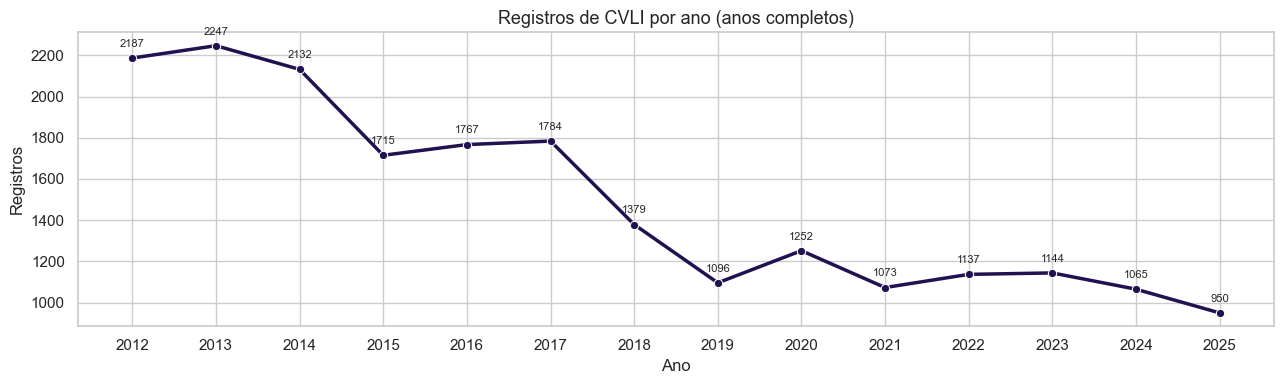

In [3]:
por_ano = df_anos_completos.groupby('ano').size().rename('registros').reset_index()

fig, ax = plt.subplots(figsize=(13, 4))
sns.lineplot(data=por_ano, x='ano', y='registros', marker='o', linewidth=2.5, ax=ax)
for _, row in por_ano.iterrows():
    ax.annotate(f"{int(row['registros'])}", (row['ano'], row['registros']),
                textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
ax.set_title('Registros de CVLI por ano (anos completos)', fontsize=13)
ax.set_xlabel('Ano')
ax.set_ylabel('Registros')
ax.set_xticks(por_ano['ano'])
plt.tight_layout()


## 4. Sazonalidade mensal

Existem meses sistematicamente mais violentos? Esse padrao se repete ao longo dos anos?


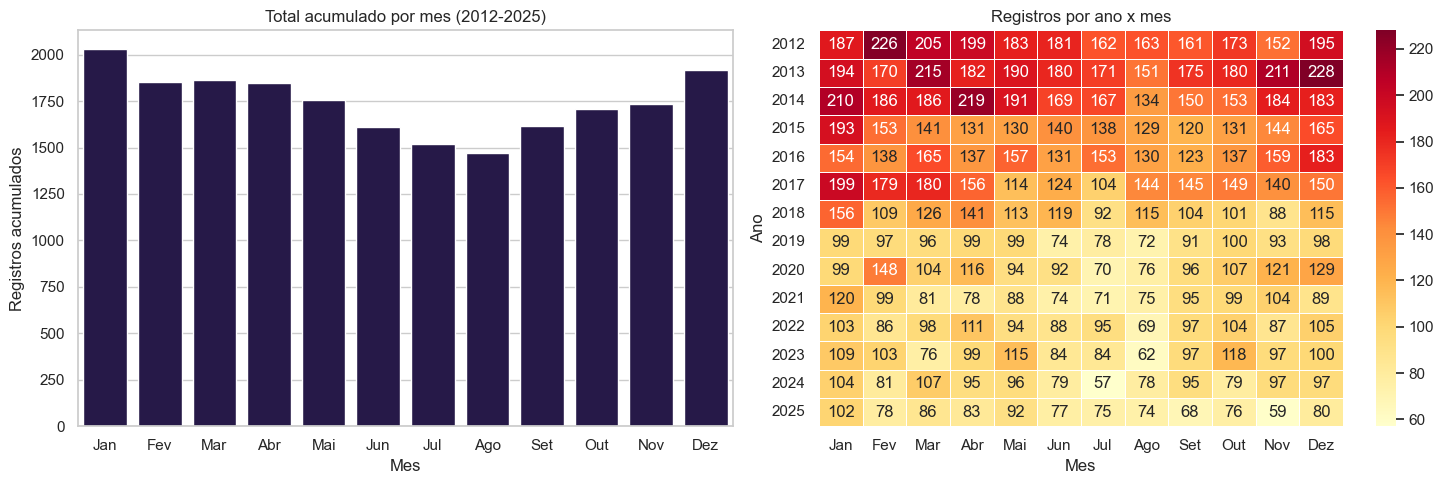

In [4]:
por_mes = df_anos_completos.groupby('mes').size().rename('total').reset_index()
nomes_mes = {1:'Jan',2:'Fev',3:'Mar',4:'Abr',5:'Mai',6:'Jun',
             7:'Jul',8:'Ago',9:'Set',10:'Out',11:'Nov',12:'Dez'}
por_mes['mes_nome'] = por_mes['mes'].map(nomes_mes)

# Media mensal por ano para mostrar variabilidade
anos_disp = df_anos_completos['ano'].nunique()
por_mes['media_por_ano'] = (por_mes['total'] / anos_disp).round(1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=por_mes, x='mes_nome', y='total', ax=axes[0])
axes[0].set_title('Total acumulado por mes (2012-2025)')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Registros acumulados')

# Heatmap: ano x mes
heat_ano_mes = df_anos_completos.pivot_table(index='ano', columns='mes', values='ID_CONTROLE', aggfunc='count')
heat_ano_mes.columns = [nomes_mes[m] for m in heat_ano_mes.columns]
sns.heatmap(heat_ano_mes, cmap='YlOrRd', annot=True, fmt='.0f', linewidths=0.5, ax=axes[1])
axes[1].set_title('Registros por ano x mes')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Ano')

plt.tight_layout()


## 5. Padrao semanal e intradiario

Heatmap dia da semana x hora do dia revela as 'janelas temporais' de maior risco.


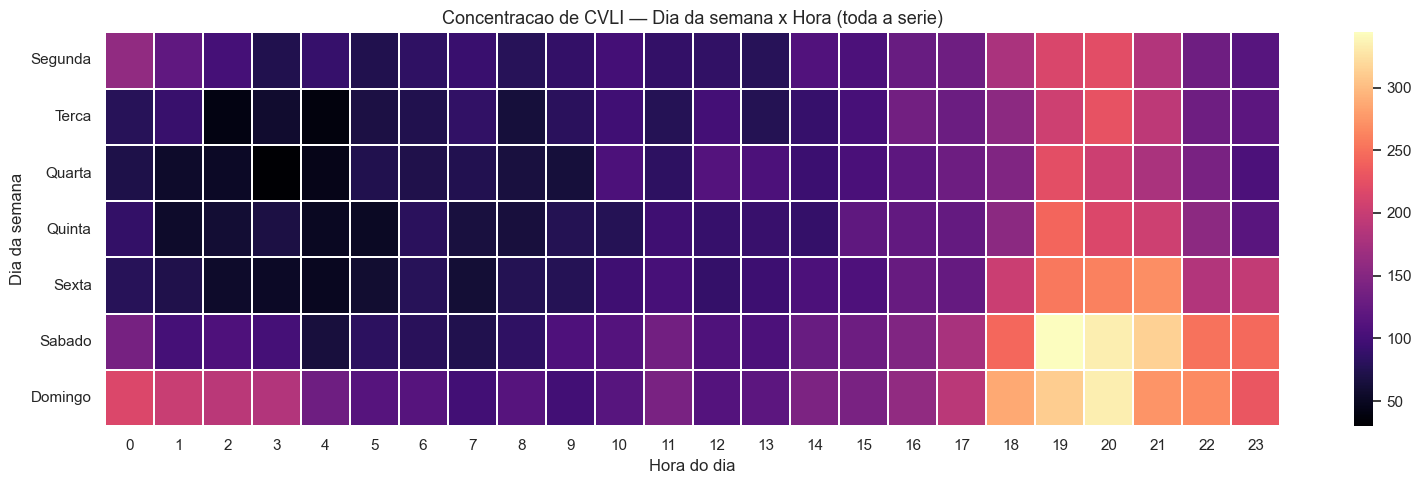

In [5]:
ordem_dias = ['Segunda', 'Terca', 'Quarta', 'Quinta', 'Sexta', 'Sabado', 'Domingo']

heat_semanal = (
    df.pivot_table(index='dia_semana', columns='hora', values='ID_CONTROLE', aggfunc='count')
    .reindex(ordem_dias)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heat_semanal, cmap='magma', ax=ax, linewidths=0.3)
ax.set_title('Concentracao de CVLI — Dia da semana x Hora (toda a serie)', fontsize=13)
ax.set_xlabel('Hora do dia')
ax.set_ylabel('Dia da semana')
plt.tight_layout()


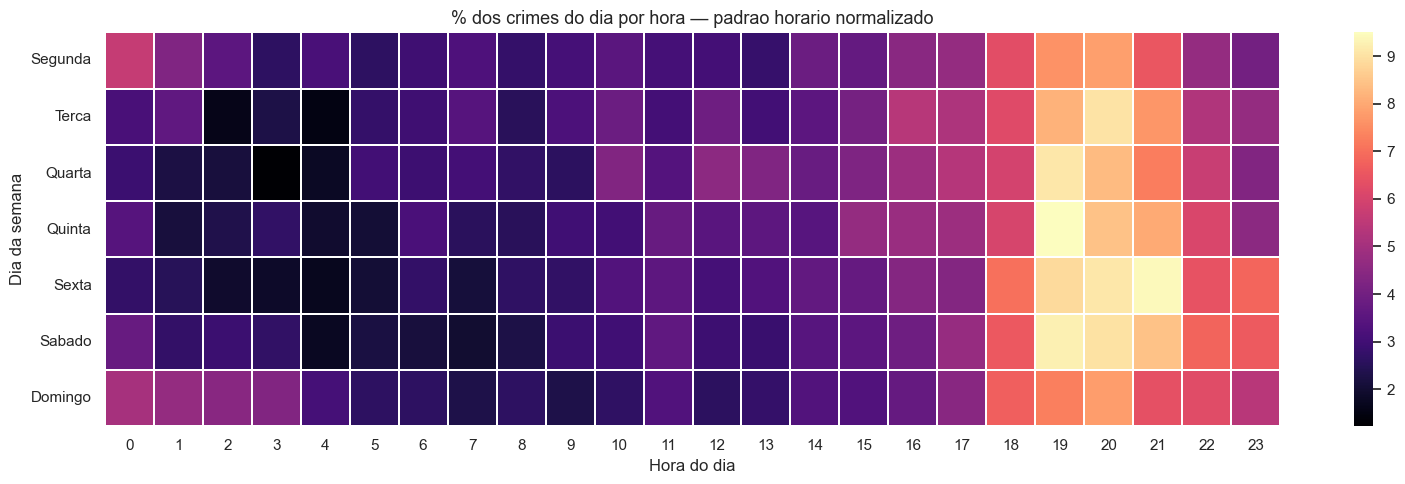

In [6]:
# Normalizado por linha: permite comparar o padrao horario independente do volume total do dia
heat_norm = heat_semanal.div(heat_semanal.sum(axis=1), axis=0).mul(100)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heat_norm, cmap='magma', fmt='.1f', ax=ax, linewidths=0.3)
ax.set_title('% dos crimes do dia por hora — padrao horario normalizado', fontsize=13)
ax.set_xlabel('Hora do dia')
ax.set_ylabel('Dia da semana')
plt.tight_layout()


## 6. Top cidades — evolucao ao longo dos anos

Algumas cidades concentram sistematicamente mais violencia?
A tendencia dessas cidades segue a media estadual ou diverge?


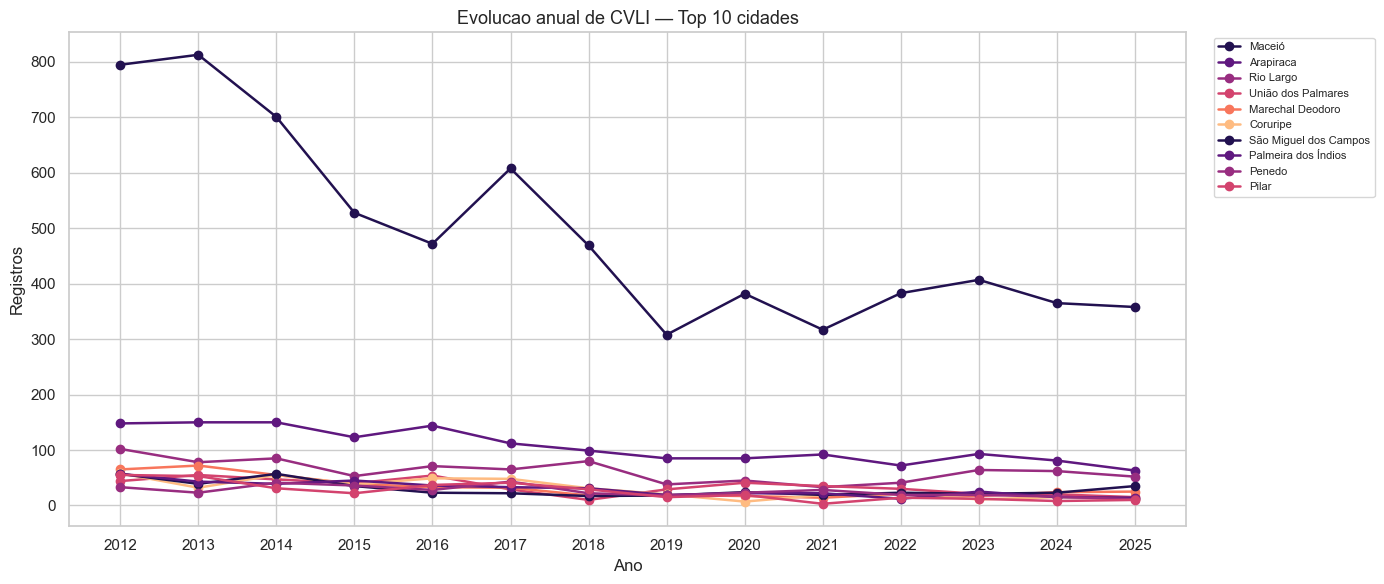

In [7]:
top10_cidades = df['CIDADE DO FATO'].value_counts().head(10).index.tolist()

evolucao_cidades = (
    df_anos_completos[df_anos_completos['CIDADE DO FATO'].isin(top10_cidades)]
    .groupby(['ano', 'CIDADE DO FATO'])
    .size()
    .reset_index(name='registros')
)

fig, ax = plt.subplots(figsize=(14, 6))
for cidade in top10_cidades:
    sub = evolucao_cidades[evolucao_cidades['CIDADE DO FATO'] == cidade]
    ax.plot(sub['ano'], sub['registros'], marker='o', label=cidade, linewidth=1.8)
ax.set_title('Evolucao anual de CVLI — Top 10 cidades', fontsize=13)
ax.set_xlabel('Ano')
ax.set_ylabel('Registros')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.set_xticks(sorted(df_anos_completos['ano'].dropna().astype(int).unique()))
plt.tight_layout()


In [8]:
# Participacao percentual das top 10 cidades no total estadual
total_por_ano = df_anos_completos.groupby('ano').size().rename('total_estado')
evolucao_cidades = evolucao_cidades.merge(total_por_ano.reset_index(), on='ano')
evolucao_cidades['pct_estado'] = 100 * evolucao_cidades['registros'] / evolucao_cidades['total_estado']

pivot_pct = evolucao_cidades.pivot(index='CIDADE DO FATO', columns='ano', values='pct_estado').round(1)
display(pivot_pct)


ano,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
CIDADE DO FATO,,,,,,,,,,,,,,
Arapiraca,6.8,6.7,7.0,7.2,8.1,6.3,7.2,7.8,6.8,8.6,6.3,8.1,7.6,6.6
Coruripe,2.7,1.4,2.6,2.2,2.8,2.7,2.2,1.8,0.6,1.8,1.8,1.0,1.4,1.3
Maceió,36.4,36.2,32.9,30.8,26.7,34.1,34.0,28.1,30.5,29.5,33.7,35.6,34.3,37.7
Marechal Deodoro,3.0,3.2,2.6,2.3,1.9,1.8,1.3,1.7,1.4,1.3,1.8,1.5,2.3,2.6
Palmeira dos Índios,2.6,1.9,1.8,2.6,2.0,1.8,2.2,1.7,1.8,2.1,1.1,2.2,1.4,1.5
Penedo,1.5,1.0,1.9,2.1,1.6,2.4,1.6,1.6,1.8,2.6,1.7,1.7,1.5,1.2
Pilar,2.5,2.4,1.5,1.3,2.1,2.3,2.1,1.4,1.5,0.3,1.2,1.0,0.8,1.1
Rio Largo,4.7,3.5,4.0,3.1,4.0,3.6,5.8,3.5,3.6,3.1,3.6,5.6,5.8,5.5
São Miguel dos Campos,2.6,1.7,2.7,2.0,1.3,1.2,1.2,1.6,1.9,1.8,2.0,1.8,2.2,3.7


## 7. Maceio x Interior

Separar a capital do restante do estado revela se a violencia e um fenomeno
concentrado na capital ou distribuido pelo interior.


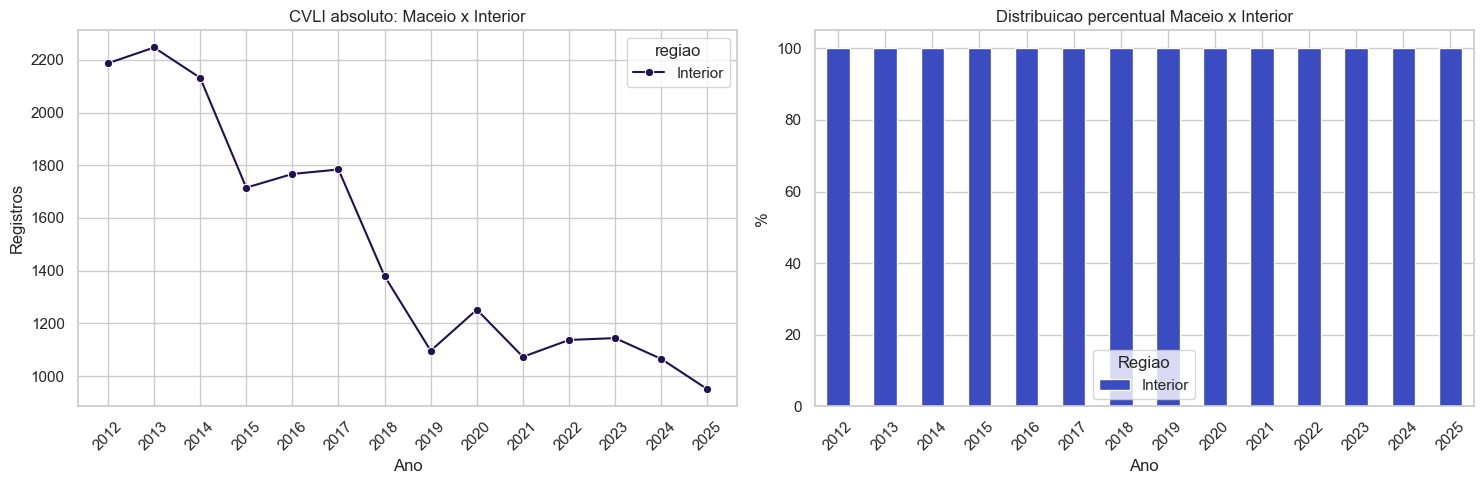

In [9]:
df_anos_completos['regiao'] = df_anos_completos['CIDADE DO FATO'].apply(
    lambda c: 'Maceio' if str(c).strip().upper() == 'MACEIO' else 'Interior'
)

regiao_ano = (
    df_anos_completos.groupby(['ano', 'regiao'])
    .size()
    .reset_index(name='registros')
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(data=regiao_ano, x='ano', y='registros', hue='regiao', marker='o', ax=axes[0])
axes[0].set_title('CVLI absoluto: Maceio x Interior')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Registros')
axes[0].set_xticks(sorted(df_anos_completos['ano'].dropna().astype(int).unique()))
axes[0].tick_params(axis='x', rotation=45)

pct_regiao = regiao_ano.pivot(index='ano', columns='regiao', values='registros')
pct_regiao = pct_regiao.div(pct_regiao.sum(axis=1), axis=0).mul(100)
pct_regiao.plot(kind='bar', stacked=True, ax=axes[1], colormap='coolwarm')
axes[1].set_title('Distribuicao percentual Maceio x Interior')
axes[1].set_ylabel('%')
axes[1].set_xlabel('Ano')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Regiao')

plt.tight_layout()


## 8. Janelas de risco — combinacoes dia x hora x cidade

Identificar as combinacoes (cidade, dia da semana, hora) com maior concentracao absoluta de crimes.
Essas 'janelas de risco' sao diretamente acionaveis para alocacao de policiamento.


In [10]:
# Top 5 cidades para a analise de janelas
top5 = df['CIDADE DO FATO'].value_counts().head(5).index.tolist()

df_top5 = df[df['CIDADE DO FATO'].isin(top5)].copy()
df_top5 = df_top5.dropna(subset=['hora', 'dia_semana'])

janelas = (
    df_top5.groupby(['CIDADE DO FATO', 'dia_semana', 'hora'])
    .size()
    .reset_index(name='registros')
    .sort_values('registros', ascending=False)
)

print('Top 30 janelas de risco (cidade + dia + hora):')
display(janelas.head(30))


Top 30 janelas de risco (cidade + dia + hora):


,CIDADE DO FATO,dia_semana,hora,registros
187,Maceió,Domingo,20,107
258,Maceió,Sabado,19,106
260,Maceió,Sabado,21,105
186,Maceió,Domingo,19,102
307,Maceió,Sexta,20,96
308,Maceió,Sexta,21,96
185,Maceió,Domingo,18,94
262,Maceió,Sabado,23,91
259,Maceió,Sabado,20,90
261,Maceió,Sabado,22,89


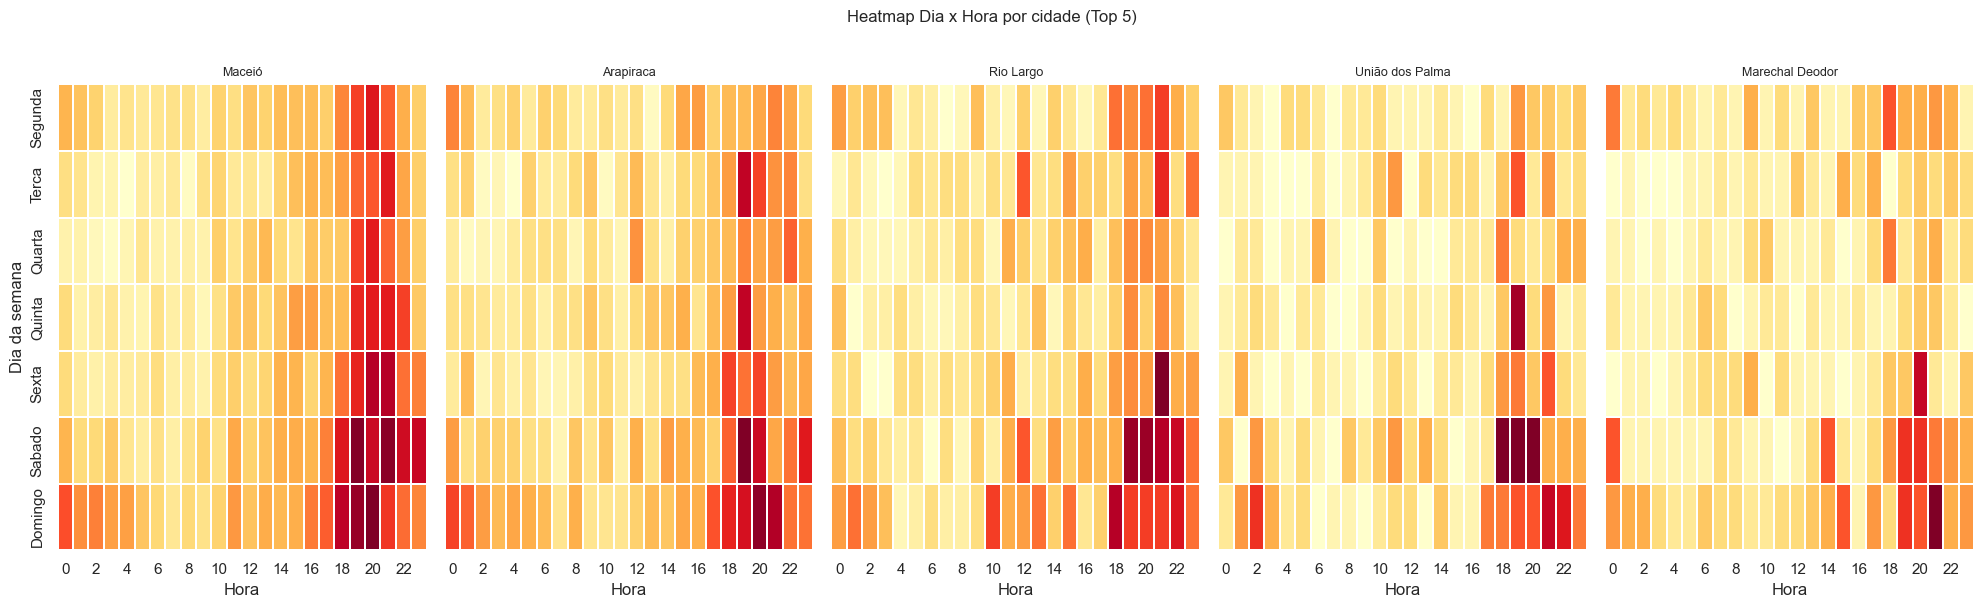

In [11]:
# Heatmap individual para cada cidade do top 5
fig, axes = plt.subplots(1, len(top5), figsize=(4 * len(top5), 6), sharey=True)
ordem_dias = ['Segunda', 'Terca', 'Quarta', 'Quinta', 'Sexta', 'Sabado', 'Domingo']

for ax, cidade in zip(axes, top5):
    sub = df_top5[df_top5['CIDADE DO FATO'] == cidade]
    heat = (
        sub.pivot_table(index='dia_semana', columns='hora', values='ID_CONTROLE', aggfunc='count')
        .reindex(ordem_dias)
        .fillna(0)
    )
    sns.heatmap(heat, cmap='YlOrRd', ax=ax, cbar=False, linewidths=0.2)
    ax.set_title(cidade[:15], fontsize=9)
    ax.set_xlabel('Hora')
    ax.set_ylabel('')

axes[0].set_ylabel('Dia da semana')
fig.suptitle('Heatmap Dia x Hora por cidade (Top 5)', fontsize=12, y=1.01)
plt.tight_layout()


## 9. Periodo do dia x instrumento x cidade

Valida se o padrao de instrumento varia por horario e por cidade — refinando os insights do notebook 03.


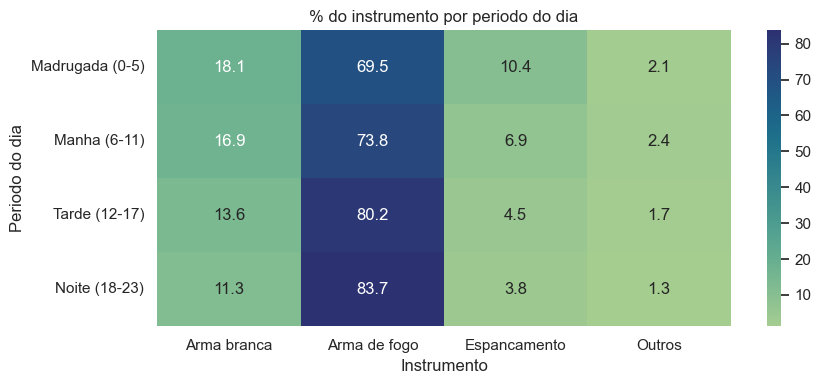

In [12]:
periodo_inst = (
    df.dropna(subset=['periodo_dia', 'grupo_instrumento'])
    .groupby(['periodo_dia', 'grupo_instrumento'])
    .size()
    .reset_index(name='n')
)

heat_pi = periodo_inst.pivot(index='periodo_dia', columns='grupo_instrumento', values='n').fillna(0)
heat_pi_pct = heat_pi.div(heat_pi.sum(axis=1), axis=0).mul(100)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(heat_pi_pct, annot=True, fmt='.1f', cmap='crest', ax=ax)
ax.set_title('% do instrumento por periodo do dia')
ax.set_xlabel('Instrumento')
ax.set_ylabel('Periodo do dia')
plt.tight_layout()


## 10. Conclusoes para gestores de seguranca publica

Com base nos resultados acima, preencha os insights abaixo com os numeros reais:

**Sazonalidade:**
- Meses de pico: (preencher)
- Meses de menor incidencia: (preencher)
- Tendencia estadual (crescimento/queda): (preencher)

**Padrao semanal/diario:**
- Dia da semana com maior concentracao: (preencher)
- Faixa horaria critica: (preencher — ex: 20h-23h concentra X% dos crimes)

**Concentracao espacial:**
- Top 3 cidades: (preencher)
- Maceio representa X% do total estadual.
- Cidade com maior crescimento nos ultimos 5 anos: (preencher)

**Janelas de risco acionaveis para policiamento:**
- Janela 1: (cidade + dia + hora) → X registros historicos
- Janela 2: ...
- Janela 3: ...

**Decisao recomendada:**
> Alocar X% a mais de efetivo em [cidade] nas [horas] de [dias] com foco em
> policiamento ostensivo em [tipo de local], reduzindo a janela de maior risco historico.
